# Proxy Statistics

In [1]:
import os
import re
import json
from common import *
from collections import defaultdict
from data import RawDataFile
from experiment import Treatment, NetworkSetting
from treatments.picoquic import treatment_map as http_treatment_map
from treatments.media import treatment_map as media_treatment_map

## Collect data

```
# Build the proxy with debug logging of cache statistics
cd $SIDEKICK_HOME/proxy/
cargo build --release --bin sidekick --features cache_statistics
```

In [2]:
# Make the data directory
http_data_home = f'{DATA_HOME}/proxy_statistics/http'
media_data_home = f'{DATA_HOME}/proxy_statistics/media'
os.system(f'mkdir -p {http_data_home}')
os.system(f'mkdir -p {media_data_home}')

0

In [3]:
# HTTP benchmark
def gen_http_cmd(label, time_s):
    treatment = http_treatment_map[label]
    network_setting = NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=4, loss2=0)
    data_size = 125000 * 20 * time_s # 125000 * bottleneck_bw * time_s
    return RawDataFile(treatment, network_setting, '').cmd(data_size=data_size, num_trials=1, debug=True, logdir=http_data_home)

print(gen_http_cmd('picoquic_sidekick_30ms', 60))

sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 -t 1 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/http --label picoquic_sidekick_30ms --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 20 --network-statistics picoquic --client-quacker --ack-delay 30 -n 150000000


In [4]:
# Media benchmark
def gen_media_cmd(label, time_s):
    treatment = media_treatment_map[label]
    network_setting = NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=4, loss2=0)
    return RawDataFile(treatment, network_setting, '').cmd(duration=time_s, debug=True, logdir=media_data_home)

print(gen_media_cmd('psum_delay45', 480))

sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/media --label psum_delay45 --proxy sidekick --freq-ms 0 --threshold 8 --freq-pkts 2 --network-statistics media --client-quacker --ack-delay 45 --duration 480


## Decode statistics

In [5]:
def parse_decode_statistics(data_home, normalize=True):
    # Read the raw data file
    filename = f'{data_home}/router.log'
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Parse the number of missing elements in each decoded quACK
    data = defaultdict(lambda: 0)
    for line in lines:
        match = re.search(r'quack (\d+) cache_len=(\d+) last_index=(\d+) missing=(\[[\d, ]+\]),', line)
        if not match:
            continue
        _count = int(match.group(1))
        _cache_len = int(match.group(2))
        _last_index = int(match.group(3))
        missing = json.loads(match.group(4))
        data[len(missing)] += 1

    # Possibly normalize data
    total = sum(data.values())
    print(total)
    if normalize:
        for key in data.keys():
            data[key] /= total
    return data

In [6]:
http_data = parse_decode_statistics(http_data_home)
media_data = parse_decode_statistics(media_data_home)
decode_statistics_data = [http_data, media_data]

1994
920


In [7]:
def plot_decode_statistics(all_data, labels, pdf=None):
    plt.figure(figsize=(6, 3))

    # Get the full x range across all dictionaries
    keys = set()
    for data in all_data:
        keys |= set(data.keys())
    keys = sorted(keys)
    
    # Width of bars, slightly narrower so they don't completely overlap
    bar_width = 1
    colors = ['blue', 'yellow']
    for i, data in enumerate(all_data):
        plot_data = [data.get(k, 0) for k in keys]
        plt.bar(keys, plot_data, width=bar_width, alpha=0.6, label=labels[i], color=colors[i])
    
    plt.xlabel('Num Missing in QuACK Decodes')
    plt.ylabel('Count')
    plt.xticks(keys)
    plt.legend()
    plt.tight_layout()
    if pdf:
        save_pdf(pdf)
    plt.show()

../figures/decode_statistics.pdf


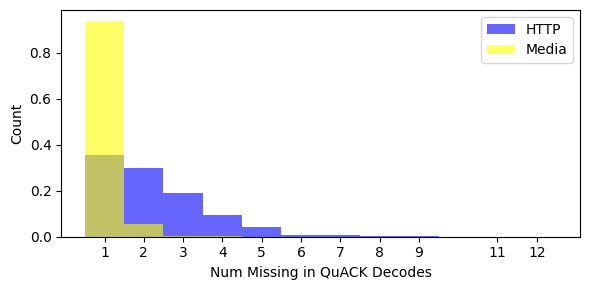

In [8]:
plot_decode_statistics(decode_statistics_data, ['HTTP', 'Media'], pdf='../figures/decode_statistics.pdf')

## Cache statistics

In [9]:
def parse_cache_statistics(data_home):
    # Read the raw data file
    filename = f'{data_home}/router.log'
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Parse the raw data
    xs = [] # time, in secs
    ys = [] # cache size, in bytes
    for line in lines:
        match = re.search(r'cache_statistics Instant { tv_sec: (\d+), tv_nsec: (\d+) } (\w+) (\d+)', line)
        if not match:
            continue
        tv_sec = int(match.group(1))
        tv_nsec = int(match.group(2))
        event = match.group(3)
        nbytes = int(match.group(4))
        xs.append(tv_sec + tv_nsec / 1000000000.0)
        ys.append(nbytes)

    # Normalize data
    print(len(xs))
    xmin = xs[0]
    xs = [x - xmin for x in xs]
    ys = [y / 1000.0 for y in ys] # bytes to kB
    return { 'xs': xs, 'ys': ys }

In [10]:
http_data = parse_cache_statistics(http_data_home)
media_data = parse_cache_statistics(media_data_home)
cache_statistics_data = [http_data, media_data]

114126
36339


In [11]:
def plot_cache_statistics(all_data, labels, xlim=0, pdf=None):
    plt.figure(figsize=(6, 3))

    colors = ['blue', 'yellow']
    for i, data in enumerate(all_data):
        plt.step(data['xs'], data['ys'], where='post', label=labels[i], color=colors[i])
    
    plt.xlabel('Time (s)')
    plt.ylabel('Cache Size (kB)')
    plt.xlim(xlim)
    plt.ylim(0)
    plt.legend()
    plt.tight_layout()
    if pdf:
        save_pdf(pdf)
    plt.show()

../figures/cache_statistics.pdf


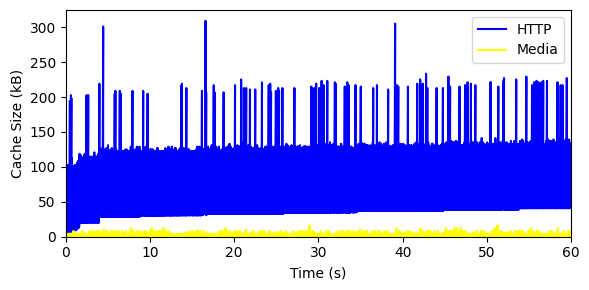

In [12]:
plot_cache_statistics(cache_statistics_data, ['HTTP', 'Media'], xlim=(0, 60), pdf='../figures/cache_statistics.pdf')